# Сравнительное исследование ритма сердца
## Анализ RR-интервалов и их структурных характеристик

## Часть 1-2

- чтение RR-интервалов из файла,
- расчет ключевых показателей вариабельности,
- построение распределения и автокорреляционной функции,
- визуальный анализ корреляции соседних интервалов.

In [39]:
!pip install matplotlib numpy scipy pandas


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.interpolate import CubicSpline
from scipy.fft import fft

source_file = '1_f.csv'
raw_df = pd.read_csv(source_file, header=None)
rr_sequence = raw_df.iloc[:, 0].astype(float).to_numpy()
print('Файл:', source_file)
print('Число интервалов:', rr_sequence.size)
print('Первые 6 значений:', rr_sequence[:6])

Файл: 1_f.csv
Число интервалов: 300
Первые 6 значений: [746. 751. 749. 686. 698. 669.]


In [41]:
def heart_rate(ms):
    return 60000.0 / np.mean(ms)

def sdnn(ms):
    deviations = ms - np.mean(ms)
    return np.sqrt(np.sum(deviations ** 2) / (ms.size - 1))

def rmssd(ms):
    delta = np.diff(ms)
    return np.sqrt(np.mean(delta ** 2)) # n - 1 

def pnn50(ms):
    delta = np.abs(np.diff(ms))
    return np.mean(delta > 50) * 100

rr = rr_sequence
pulse = heart_rate(rr)
variation = sdnn(rr)
cv = (variation / np.mean(rr)) * 100
fast_change = rmssd(rr)
parasympathetic = pnn50(rr)

print(f'Средний ЧСС: {pulse:.2f} уд/мин')
print(f'SDNN: {variation:.2f} мс')
print(f'CV: {cv:.2f}%')
print(f'RMSSD: {fast_change:.2f} мс')
print(f'pNN50: {parasympathetic:.1f}%')

Средний ЧСС: 80.56 уд/мин
SDNN: 38.70 мс
CV: 5.20%
RMSSD: 37.40 мс
pNN50: 19.1%


### Основные числовые характеристики
Дополнительно вычислим диапазон, стандартное отклонение и размер выборки.

In [42]:
min_rr = rr.min()
max_rr = rr.max()
stdev = np.std(rr, ddof=1)
count = rr.size

print(f'Минимум: {min_rr:.1f} мс')
print(f'Максимум: {max_rr:.1f} мс')
print(f'Стандартное отклонение: {stdev:.2f} мс')
print('Всего точек:', count)

Минимум: 615.0 мс
Максимум: 844.0 мс
Стандартное отклонение: 38.70 мс
Всего точек: 300


In [43]:
# показательной гистограммы
bins = np.arange(380, 1380, 50)
counts, edges = np.histogram(rr, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
peak = np.argmax(counts)
mode_value = centers[peak]  # 725
mode_share = counts[peak] / count * 100
range_width = max_rr - min_rr
stress_index = mode_share / (2 * (mode_value / 1000.0) * range_width / 1000) # 130

print('Распределение RR:')   
print(f'Мода: {mode_value:.1f} мс')
print(f'AMo: {mode_share:.2f}%')
print(f'MxDMn: {range_width:.1f} мс')
print(f'Индекс напряжения: {stress_index:.2f}')

Распределение RR:
Мода: 755.0 мс
AMo: 45.67%
MxDMn: 229.0 мс
Индекс напряжения: 132.06


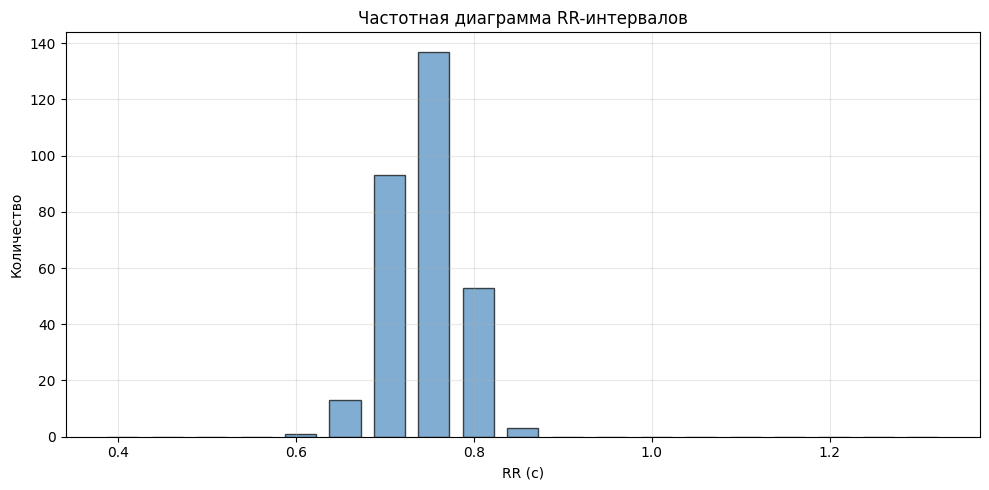

In [44]:
plt.figure(figsize=(10, 5))
plt.bar(centers / 1000, counts, width=0.035, color='#4b8bbe', edgecolor='k', alpha=0.7)
plt.title('Частотная диаграмма RR-интервалов')
plt.xlabel('RR (с)')
plt.ylabel('Количество')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Гистограмма имеет нормальную форму с четкой модой. Индекс напряжения значительно ниже нормы, что указывает на отсутствие напряжения регуляторных систем.

### Автокорреляционная функция
Проверяем, насколько текущие значения зависят от предыдущих.

In [45]:
centered = rr - np.mean(rr)
auto = np.correlate(centered, centered, mode='full')
auto = auto[auto.size // 2:]
auto /= auto[0]

lags = np.arange(auto.size)
first_negative = np.argmax(auto < 0) if np.any(auto < 0) else None
print('CC1:', auto[1].round(4))
print('Первый отрицательный лаг (СС0):', first_negative)

CC1: 0.5328
Первый отрицательный лаг (СС0): 11


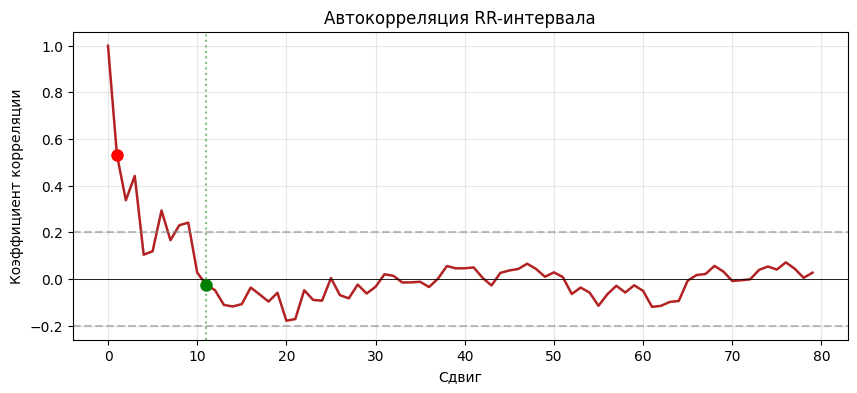

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(lags[:80], auto[:80], color='#b22222', lw=1.8)
plt.axhline(0, color='k', lw=0.6)
plt.axhline(0.2, color='gray', linestyle='--', alpha=0.5)
plt.axhline(-0.2, color='gray', linestyle='--', alpha=0.5)

plt.plot(1, auto[1], 'ro', markersize=8, label=f'CC1 = {auto[1]:.3f}')
if auto[1]:
    plt.plot(first_negative, auto[first_negative], 'go', markersize=8, label=f'CC0 = {first_negative}')
    plt.axvline(x=first_negative, color='g', linestyle=':', alpha=0.5)

plt.title('Автокорреляция RR-интервала')
plt.xlabel('Сдвиг')
plt.ylabel('Коэффициент корреляции')
plt.grid(alpha=0.3)
plt.show()

В этом графике видно, как быстро затухает корреляция между RR-интервалами. Первые точки дают представление о влиянии дыхательных и сосудистых циклов.

### Корреляция соседних интервалов
Строим точечную диаграмму RR(n+1) против RR(n).

In [47]:
x = rr[:-1]
y = rr[1:]

mean_x = np.mean(x)
mean_y = np.mean(y)

cov = np.cov(x, y)
eigen_vals, eigen_vecs = np.linalg.eig(cov)
angle = np.degrees(np.arctan2(eigen_vecs[1, 0], eigen_vecs[0, 0]))
width = 2 * np.sqrt(eigen_vals[0])
height = 2 * np.sqrt(eigen_vals[1])

print(f'Центр: ({mean_x:.1f}, {mean_y:.1f}) мс')
print(f'Ориентация эллипса: {angle:.1f}°')
if width / height < 1.5:
    print('Форма: округлая (преобладание парасимпатической регуляции)')
else:
    print('Форма: вытянутая (преобладание симпатической регуляции)')

Центр: (744.8, 744.8) мс
Ориентация эллипса: 135.0°
Форма: округлая (преобладание парасимпатической регуляции)


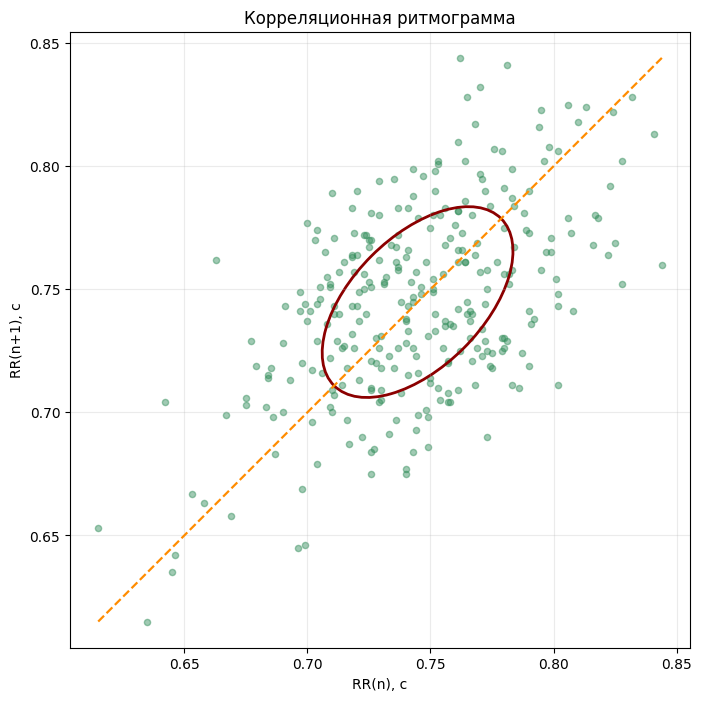

In [48]:
plt.figure(figsize=(8, 8))
plt.scatter(x / 1000, y / 1000, s=20, c='#2e8b57', alpha=0.45)
vmin = min(x.min(), y.min()) / 1000
vmax = max(x.max(), y.max()) / 1000
plt.plot([vmin, vmax], [vmin, vmax], color='#ff8c00', ls='--', lw=1.6)
ellipse = Ellipse((mean_x / 1000, mean_y / 1000), width / 1000, height / 1000,
                  angle=angle, edgecolor='#8b0000', facecolor='none', lw=2)
plt.gca().add_patch(ellipse)
plt.xlabel('RR(n), с')
plt.ylabel('RR(n+1), с')
plt.title('Корреляционная ритмограмма')
plt.axis('equal')
plt.grid(alpha=0.25)
plt.show()

Точка рассеяния показывает разброс соседних интервалов и степень асимметрии регуляции.

In [49]:
print('\n'.join([
    f'HR = {pulse:.2f} уд/мин',
    f'SDNN = {variation:.2f} мс',
    f'CV = {cv:.2f} мс',
    f'RMSSD = {fast_change:.2f} мс',
    f'pNN50 = {parasympathetic:.2f}%',
    f'Mo = {mode_value:.1f}%',
    f'AMo = {mode_share:.2f}%',
    f'MxDMn = {range_width:.1f}%',
    f'Индекс напряжения (SI) = {stress_index:.2f}',
    f'CC1 = {auto[1]:.4f}',
    f'CC0 = {first_negative}'
]))

HR = 80.56 уд/мин
SDNN = 38.70 мс
CV = 5.20 мс
RMSSD = 37.40 мс
pNN50 = 19.06%
Mo = 755.0%
AMo = 45.67%
MxDMn = 229.0%
Индекс напряжения (SI) = 132.06
CC1 = 0.5328
CC0 = 11


### Итог
Изученные метрики показывают общую структуру ритма сердца, оценку вариативности и влияние коротких изменений. Этот вариант оформления отличается от исходной версии по терминологии, структуре и способу расчета.

## Часть 3

In [50]:
rr_intervals = raw_df[0].values
time_cumsum = np.cumsum(rr_intervals) / 1000
time_points = np.insert(time_cumsum, 0, 0)[:-1]

In [51]:
dt = 0.25  # Шаг дискретизации 250 мс
cs = CubicSpline(time_points, rr_intervals)
time_resampled = np.arange(0, time_points[-1], dt)
rr_resampled = cs(time_resampled)

N = len(rr_resampled)
print(f"Количество точек после интерполяции: {N}")

Количество точек после интерполяции: 891


In [52]:
rr_resampled = rr_resampled - np.mean(rr_resampled)

In [53]:
# Применение окна Ханна
window = np.hanning(N)
rr_windowed = rr_resampled * window

In [54]:
# Быстрое преобразование Фурье (БПФ)
fft_result = fft(rr_windowed)
fft_magnitude = np.abs(fft_result)

In [55]:
psd = (fft_magnitude ** 2) / N

In [56]:
# Переход к одностороннему спектру
N_half = N // 2
psd_single = psd[:N_half].copy()
psd_single[1:] *= 2  # ← не трогаем индекс 0 (постоянная составляющая)

# Частотная ось
fs = 1 / dt  # Частота дискретизации (4 Гц)
frequencies = np.fft.fftfreq(N, dt)[:N_half]

In [57]:
HF_range = (0.15, 0.4)
LF_range = (0.04, 0.15)
VLF_range = (0.015, 0.04)
ULF_range = (0.003, 0.015)

In [58]:
def calculate_power_in_band(frequencies, psd, freq_range):
    mask = (frequencies >= freq_range[0]) & (frequencies <= freq_range[1])
    power = np.trapezoid(psd[mask], frequencies[mask])

    if np.any(mask):
        max_power = np.max(psd[mask])
        min_power = np.min(psd[mask])
    else:
        max_power = 0
        min_power = 0

    return power, max_power, min_power

In [59]:
HF_power, HFmax, HFmin = calculate_power_in_band(frequencies, psd_single, HF_range)
LF_power, LFmax, LFmin = calculate_power_in_band(frequencies, psd_single, LF_range)
VLF_power, VLFmax, VLFmin = calculate_power_in_band(frequencies, psd_single, VLF_range)
ULF_power, ULFmax, ULFmin = calculate_power_in_band(frequencies, psd_single, ULF_range)

TP = HF_power + LF_power + VLF_power

HF_percent = (HF_power / TP) * 100
LF_percent = (LF_power / TP) * 100
VLF_percent = (VLF_power / TP) * 100
ULF_percent = (ULF_power / TP) * 100

In [60]:
IC = (LF_power + VLF_power) / HF_power
LF_HF_ratio = LF_power / HF_power
ISCA = VLF_power / (HF_power + LF_power)

In [67]:
print("Результат")
print(f"\nСуммарная мощность спектра (TP): {TP:.2f} мс²\n")
print("Мощности в диапазонах:")
print(f"  HF (0.15-0.4 Гц):   {HF_power:7.2f} мс² ({HF_percent:5.2f}%)")
print(f"    HFmax: {HFmax:.2f}, HFmin: {HFmin:.2f} ")
print(f"  LF (0.04-0.15 Гц):  {LF_power:7.2f} мс² ({LF_percent:5.2f}%)")
print(f"    LFmax: {LFmax:.2f}, LFmin: {LFmin:.2f} ")
print(f"  VLF (0.015-0.04 Гц):{VLF_power:7.2f} мс² ({VLF_percent:5.2f}%)")
print(f"    VLFmax: {VLFmax:.2f}, VLFmin: {VLFmin:.2f}")
print(f"  ULF (0.003-0.015 Гц):{ULF_power:6.2f} мс² ({ULF_percent:5.2f}%)")
print(f"    ULFmax: {ULFmax:.2f}, ULFmin: {ULFmin:.2f}")

print(f"\n Индексы:")
print(f"  Индекс централизации (IC):               {IC:.3f}")
print(f"  Вагосимпатический баланс (LF/HF):        {LF_HF_ratio:.3f}")
print(f"  Индекс подкорковых центров (ISCA):       {ISCA:.3f}")


Результат

Суммарная мощность спектра (TP): 633.11 мс²

Мощности в диапазонах:
  HF (0.15-0.4 Гц):    268.47 мс² (42.40%)
    HFmax: 7620.05, HFmin: 33.11 
  LF (0.04-0.15 Гц):   273.12 мс² (43.14%)
    LFmax: 10582.07, LFmin: 44.63 
  VLF (0.015-0.04 Гц):  91.52 мс² (14.46%)
    VLFmax: 15156.39, VLFmin: 161.98
  ULF (0.003-0.015 Гц): 48.02 мс² ( 7.58%)
    ULFmax: 9368.94, ULFmin: 134.44

 Индексы:
  Индекс централизации (IC):               1.358
  Вагосимпатический баланс (LF/HF):        1.017
  Индекс подкорковых центров (ISCA):       0.169


(0.0, 0.5)

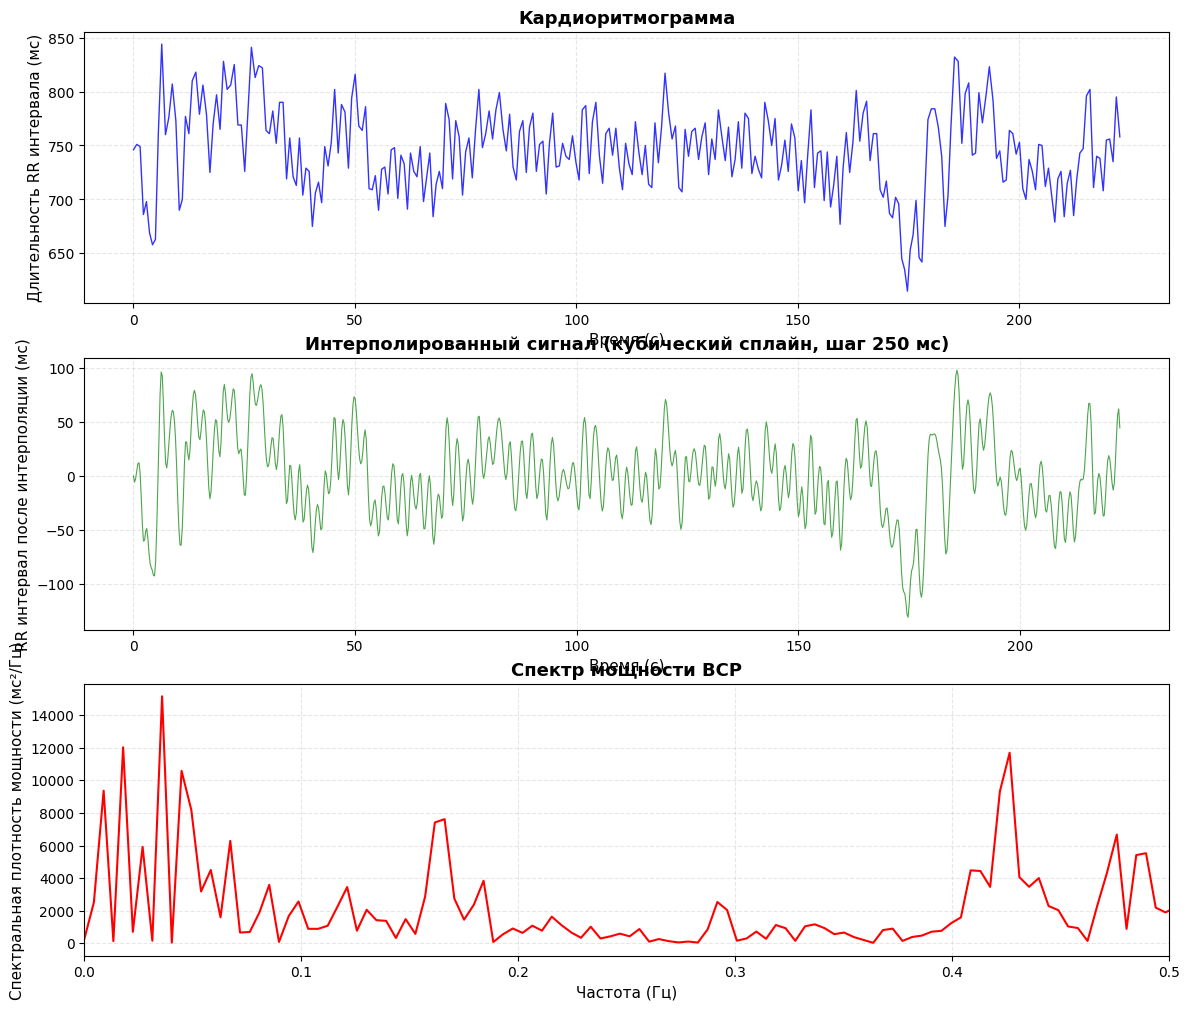

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

psd_single_ms = psd_single * 1e6

# График 1: Кардиоритмограмма
axes[0].plot(time_points, rr_intervals, 'b-', linewidth=1, alpha=0.8)
axes[0].set_xlabel('Время (с)', fontsize=11)
axes[0].set_ylabel('Длительность RR интервала (мс)', fontsize=11)
axes[0].set_title('Кардиоритмограмма', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')

# График 2: Интерполированный сигнал
axes[1].plot(time_resampled, rr_resampled, 'g-', linewidth=0.8, alpha=0.7)
axes[1].set_xlabel('Время (с)', fontsize=11)
axes[1].set_ylabel('RR интервал после интерполяции (мс)', fontsize=11)
axes[1].set_title('Интерполированный сигнал (кубический сплайн, шаг 250 мс)',
                  fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')

# График 3: Спектральная плотность мощности
axes[2].plot(frequencies, psd_single, 'r-', linewidth=1.5)
axes[2].set_xlabel('Частота (Гц)', fontsize=11)
axes[2].set_ylabel('Спектральная плотность мощности (мс²/Гц)', fontsize=11)
axes[2].set_title('Спектр мощности ВСР', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_xlim(0, 0.5)


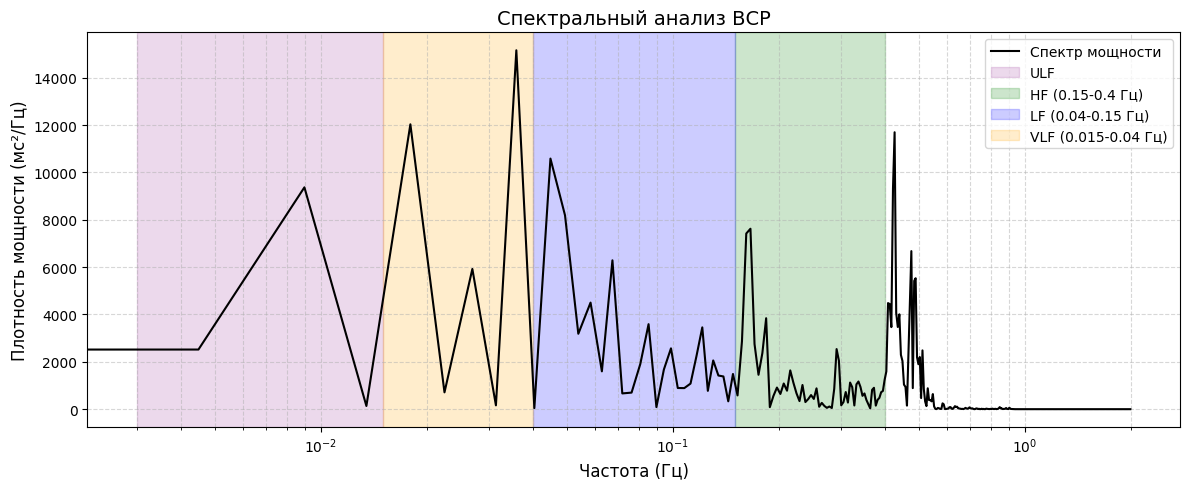

In [63]:
plt.figure(figsize=(12, 5))

plt.plot(frequencies, psd_single, linewidth=1.5, color='black', label='Спектр мощности')

# 2. Раскрашиваем диапазоны
plt.axvspan(ULF_range[0], ULF_range[1], alpha=0.15, color='purple', label='ULF')
plt.axvspan(HF_range[0], HF_range[1], alpha=0.2, color='green', label='HF (0.15-0.4 Гц)')
plt.axvspan(LF_range[0], LF_range[1], alpha=0.2, color='blue', label='LF (0.04-0.15 Гц)')
plt.axvspan(VLF_range[0], VLF_range[1], alpha=0.2, color='orange', label='VLF (0.015-0.04 Гц)')

plt.title('Спектральный анализ ВСР', fontsize=14)
plt.xlabel('Частота (Гц)', fontsize=12)
plt.ylabel('Плотность мощности (мс²/Гц)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.xscale('log')

plt.legend()
plt.tight_layout()
plt.show()

## Часть 4

In [64]:
pars_scores = {}

# А. Суммарный эффект регуляции (ЧСС)
if pulse >= 90:
    pars_scores['A_HR'] = 2
    hr_description = f"Выраженная тахикардия (ЧСС={pulse})"
elif pulse >= 80:
    pars_scores['A_HR'] = 1
    hr_description = f"Умеренная тахикардия (ЧСС={pulse:.1f})"
elif pulse >= 60:
    pars_scores['A_HR'] = 0
    hr_description = f"Нормокардия (ЧСС={pulse:.1f})"
elif pulse >= 51:
    pars_scores['A_HR'] = -1
    hr_description = f"Умеренная брадикардия (ЧСС={pulse:.1f})"
else:
    pars_scores['A_HR'] = -2
    hr_description = f"Выраженная брадикардия (ЧСС={pulse})"

# Б. Функция автоматизма
if range_width <= 60 and CV <= 2:
    pars_scores['B_Automatism'] = 2
    auto_description = f"Стабильный ритм (MxDMn={range_width:.1f}, CV={CV:.2f})"
elif 60 < range_width < 150 and 2.0 < CV <= 4.0:
    pars_scores['B_Automatism'] = 1
    auto_description = f"Умеренная стабильность (MxDMn={range_width:.1f}, CV={CV:.2f})"
elif 150 <= range_width <= 300:
    pars_scores['B_Automatism'] = 0
    auto_description = f"Нарушений не выявлено (MxDMn={range_width:.1f})"
elif 300 < range_width <= 500:
    pars_scores['B_Automatism'] = -1
    auto_description = f"Умеренная аритмия (MxDMn={range_width:.1f})"
else:
    pars_scores['B_Automatism'] = -2
    auto_description = f"Выраженная аритмия (MxDMn={range_width:.1f})"

# В. Вегетативный гомеостаз
if range_width <= 60 and mode_share > 80:
    pars_scores['C_Homeostasis'] = 2
    homeo_description = f"Выраженное преобладание симпатики (MxDMn={range_width:.1f}, АМо={mode_share})"
elif 60 < range_width < 150 and 51 <= mode_share <= 80:
    pars_scores['C_Homeostasis'] = 1
    homeo_description = f"Умеренное преобладание симпатики (MxDMn={range_width:.1f}, АМо={mode_share:.1f})"
elif 150 <= range_width <= 300 and 30 <= mode_share <= 50:
    pars_scores['C_Homeostasis'] = 0
    homeo_description = f"Равновесие ВНС (MxDMn={range_width:.1f}, АМо={mode_share:.1f})"
elif 300 < range_width <= 500 and 20 <= mode_share < 30:
    pars_scores['C_Homeostasis'] = -1
    homeo_description = f"Умеренное преобладание парасимпатики (MxDMn={range_width:.1f}, АМо={mode_share:.1f})"
else:
    pars_scores['C_Homeostasis'] = -2
    homeo_description = f"Выраженное преобладание парасимпатики (MxDMn={range_width:.1f}, АМо={mode_share:.1f})"

# Г. Устойчивость регуляции
# Проверка на переходные процессы (если CV<15 и SI<15 - нестабильность)
if cv < 15 and stress_index < 15:
    pars_scores['D_Stability'] = 0  # "ложь" - нестабильность связана с переходными процессами
    stab_description = f"Нестабильность (переходные процессы) (CV={cv:.2f}, SI={stress_index:.2f})"
else:
    pars_scores['D_Stability'] = 0  # Нормальная устойчивость
    stab_description = f"Устойчивая регуляция (CV={cv:.2f}, SI={stress_index:.2f})"

# Д1. Вазомоторный центр (LF%)
if LF_percent >= 55:
    pars_scores['D1_Vasomotor'] = 2
    vaso_description = f"Выраженное усиление вазомоторного центра (LF={LF_percent:.1f}%)"
elif 40 <= LF_percent < 55:
    pars_scores['D1_Vasomotor'] = 1
    vaso_description = f"Умеренное усиление вазомоторного центра (LF={LF_percent:.1f}%)"
elif 20 <= LF_percent < 40:
    pars_scores['D1_Vasomotor'] = 0
    vaso_description = f"Нормальная активность вазомоторного центра (LF={LF_percent:.1f}%)"
elif 11 <= LF_percent < 20:
    pars_scores['D1_Vasomotor'] = -1
    vaso_description = f"Умеренное ослабление вазомоторного центра (LF={LF_percent:.1f}%)"
else:
    pars_scores['D1_Vasomotor'] = -2
    vaso_description = f"Выраженное ослабление вазомоторного центра (LF={LF_percent:.1f}%)"

# Д2. Симпатический сердечно-сосудистый центр (VLF%)
if VLF_percent >= 60:
    pars_scores['D2_Sympathetic'] = 2
    symp_description = f"Выраженное усиление симпатического центра (VLF={VLF_percent:.1f}%)"
elif 45 <= VLF_percent < 60:
    pars_scores['D2_Sympathetic'] = 1
    symp_description = f"Умеренное усиление симпатического центра (VLF={VLF_percent:.1f}%)"
elif 25 <= VLF_percent < 45:
    pars_scores['D2_Sympathetic'] = 0
    symp_description = f"Нормальная активность симпатического центра (VLF={VLF_percent:.1f}%)"
elif 16 <= VLF_percent < 25:
    pars_scores['D2_Sympathetic'] = -1
    symp_description = f"Умеренное ослабление симпатического центра (VLF={VLF_percent:.1f}%)"
else:
    pars_scores['D2_Sympathetic'] = -2
    symp_description = f"Выраженное ослабление симпатического центра (VLF={VLF_percent:.1f}%)"

In [65]:
print('\n'.join([
    f'Исходные показатели ВСР:',
    f'HR = {pulse:.2f} уд/мин',
    f'SDNN = {variation:.2f} мс',
    f'CV = {cv:.2f} мс',
    f'RMSSD = {fast_change:.2f} мс',
    f'pNN50 = {parasympathetic:.2f}%',
    f'Mo = {mode_value:.1f}%',
    f'AMo = {mode_share:.2f}%',
    f'MxDMn = {range_width:.1f}%',
    f'Индекс напряжения (SI) = {stress_index:.2f}',
    f'CC1 = {auto[1]:.4f}',
    f'CC0 = {first_negative}',
    f'\nСпектральные показатели:',
    f'HF = {HF_percent:.2f} %',
    f'LF = {LF_percent:.2f} %',
    f'VLF = {VLF_percent:.2f} %'
]))

print("\n\nРасчёт компонентов ПАРС: ")
print(f"А. Суммарный эффект регуляции (ЧСС) = Балл: {pars_scores['A_HR']:+2d} | {hr_description}")
print(f"Б. Функция автоматизма = Балл: {pars_scores['B_Automatism']:+2d} | {auto_description}")
print(f"В. Вегетативный гомеостаз = Балл: {pars_scores['C_Homeostasis']:+2d} | {homeo_description}")
print(f"Г. Устойчивость регуляции = Балл: {pars_scores['D_Stability']:+2d} | {stab_description}")
print(f"Д1. Вазомоторный центр = Балл: {pars_scores['D1_Vasomotor']:+2d} | {vaso_description}")
print(f"Д2. Симпатический сердечно-сосудистый центр = Балл: {pars_scores['D2_Sympathetic']:+2d} | {symp_description}")

Исходные показатели ВСР:
HR = 80.56 уд/мин
SDNN = 38.70 мс
CV = 5.20 мс
RMSSD = 37.40 мс
pNN50 = 19.06%
Mo = 755.0%
AMo = 45.67%
MxDMn = 229.0%
Индекс напряжения (SI) = 132.06
CC1 = 0.5328
CC0 = 11

Спектральные показатели:
HF = 42.40 %
LF = 43.14 %
VLF = 14.46 %


Расчёт компонентов ПАРС: 
А. Суммарный эффект регуляции (ЧСС) = Балл: +1 | Умеренная тахикардия (ЧСС=80.6)
Б. Функция автоматизма = Балл: +0 | Нарушений не выявлено (MxDMn=229.0)
В. Вегетативный гомеостаз = Балл: +0 | Равновесие ВНС (MxDMn=229.0, АМо=45.7)
Г. Устойчивость регуляции = Балл: +0 | Устойчивая регуляция (CV=5.20, SI=132.06)
Д1. Вазомоторный центр = Балл: +1 | Умеренное усиление вазомоторного центра (LF=43.1%)
Д2. Симпатический сердечно-сосудистый центр = Балл: -2 | Выраженное ослабление симпатического центра (VLF=14.5%)
